# Task 1.2 — Residual Connections in Practice (Stage-by-Stage Ablation Study)

In this notebook, we perform an in-depth empirical ablation study on ResNet-152 to evaluate the functional importance of residual skip connections across network depth:
1. Load an ImageNet pre-trained ResNet-152 model.
2. Individually disable residual skip connections in the initial bottleneck block of each layer stage (`layer1_0`, `layer2_0`, `layer3_0`, `layer4_0`), as well as in all stages simultaneously (`layer1-4_0`).
3. Fine-tune each modified model architecture on CIFAR-10.
4. Compare training dynamics, loss convergence, and final classification accuracy to determine **which layer stage removal is most damaging to performance**.

In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from task1_resnet152.src.data import get_cifar10_loaders
from task1_resnet152.src.model import load_resnet152, replace_head, freeze_backbone
from task1_resnet152.src.residual_ablation import ResidualAblator
from task1_resnet152.src.train import train_model_cached
from task1_resnet152.src.visualize import plot_training_curves

# Select device (CUDA GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load Data
train_loader, val_loader = get_cifar10_loaders(batch_size=256)

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Files already downloaded and verified
Files already downloaded and verified


In [2]:
# Stage-by-Stage Ablation Execution
ablation_experiments = {
    'No Skip in Layer 1': [('layer1', 0)],
    'No Skip in Layer 2': [('layer2', 0)],
    'No Skip in Layer 3': [('layer3', 0)],
    'No Skip in Layer 4': [('layer4', 0)],
    'No Skips in All Stages': [('layer1', 0), ('layer2', 0), ('layer3', 0), ('layer4', 0)]
}

dfs = {}
# Load Baseline metrics if available
if os.path.exists('../results/logs/baseline_metrics.csv'):
    dfs['Baseline (With Skips)'] = pd.read_csv('../results/logs/baseline_metrics.csv')

for exp_name, blocks_to_disable in ablation_experiments.items():
    print(f'\n=== Running Experiment: {exp_name} ===')
    model = load_resnet152(pretrained=True)
    model = replace_head(model, num_classes=10)
    freeze_backbone(model)
    
    ablator = ResidualAblator(model)
    ablator.disable_skip_connections(blocks_to_disable)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
    
    log_filename = exp_name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '_metrics.csv'
    df_exp = train_model_cached(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        epochs=5,
        log_path=f'../results/logs/{log_filename}',
        device=device
    )
    dfs[exp_name] = df_exp


=== Running Experiment: No Skip in Layer 1 ===
Disabled skip connection in layer1_0
Caching train features …


Extracting features:   0%|          | 0/196 [00:00<?, ?it/s]C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA0\atml-assignment0\task1_resnet152\src\train.py:146: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):


Caching val features …


Epoch 1/5 | Train Loss: 1.9253 Acc: 0.3343 | Val Loss: 1.7723 Acc: 0.3939 | Time: 1.74s


Epoch 2/5 | Train Loss: 1.7169 Acc: 0.4112 | Val Loss: 1.6840 Acc: 0.4175 | Time: 1.29s


...

Epoch 1/5 | Train Loss: 2.1659 Acc: 0.2176 | Val Loss: 2.0810 Acc: 0.2654 | Time: 1.16s


Epoch 2/5 | Train Loss: 2.0374 Acc: 0.2820 | Val Loss: 1.9994 Acc: 0.2954 | Time: 1.08s


Epoch 3/5 | Train Loss: 1.9814 Acc: 0.3007 | Val Loss: 1.9568 Acc: 0.3099 | Time: 1.08s


Epoch 4/5 | Train Loss: 1.9465 Acc: 0.3106 | Val Loss: 1.9375 Acc: 0.3081 | Time: 1.14s


Epoch 5/5 | Train Loss: 1.9171 Acc: 0.3231 | Val Loss: 1.9106 Acc: 0.3217 | Time: 1.12s


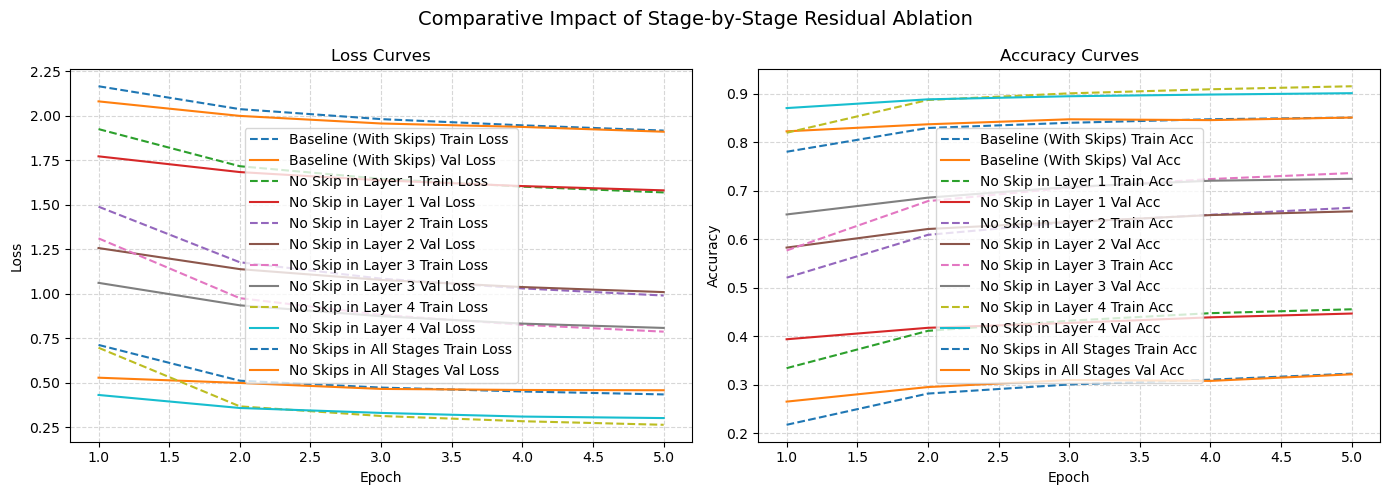

In [3]:
# Comparative Training & Validation Curves
plot_training_curves(
    dfs,
    save_path='../results/figures/residual_ablation_stage_comparison.png',
    title='Comparative Impact of Stage-by-Stage Residual Ablation'
)

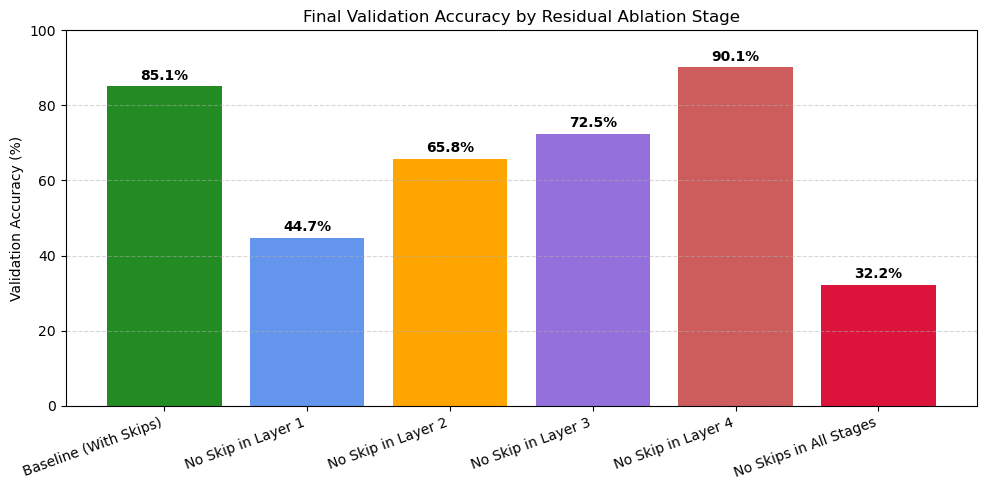

In [4]:
# Bar Chart: Final Validation Accuracy Across Stage Ablations
final_accs = {k: v['val_acc'].iloc[-1] * 100 for k, v in dfs.items()}

plt.figure(figsize=(10, 5))
bars = plt.bar(list(final_accs.keys()), list(final_accs.values()), color=['forestgreen', 'cornflowerblue', 'orange', 'mediumpurple', 'indianred', 'crimson'])
plt.ylabel('Validation Accuracy (%)')
plt.title('Final Validation Accuracy by Residual Ablation Stage')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('../results/figures/residual_ablation_stage_bar.png', bbox_inches='tight', dpi=300)
plt.show()